# Following an extraordinary IMF $B_Y$ flip through geospace

During the 10 May 2024 Gannon (Mother's Day) storm, an unusually large negative-to-positive IMF $B_Y$ reversal was observed across a region spanning lunar distances to the compressed dayside magnetosphere. A coherent ground magnetic response followed several minutes later.

This notebook uses PySPEDAS to ask one system-level question:

> **How long does a large-scale magnetic-field change take to appear at different spacecraft and in the ground magnetic response?**

We combine ARTEMIS/THEMIS-B and -C, MMS1, GOES-18, OMNI, and ground magnetometers. The emphasis is on timestamps, coordinate systems, cadence, resampling, and what a measured lag does—and does not—mean.

The principal reference is [Ohtani et al. (2025), *Ground Magnetic Response to an Extraordinary IMF $B_Y$ Flip During the May 2024 Storm*](https://doi.org/10.1029/2024JA033691****). The figures below are new diagnostic plots made from public data; they do not reproduce the paper's figures.

## 1. Imports and event interval

The paper reports that the GOES-18 $B_Y$ reversal began near 22:33:50 UT and crossed zero near 22:34:45 UT. We store those times for later comparison, but first inspect the observations without using them to align anything.

PySPEDAS 2.2.0 exposes most tplot functions directly from `pyspedas`. Pandas makes the timestamp-aware resampling and lag calculation transparent.

In [1]:
# This line installs PySPEDAS so the notebook can be used in Google Colab.  You can comment
# it out or skip this cell if you already have a suitable PySPEDAS installation.  This notebook
# uses the basemap package to render an Earth map, so your PySPEDAS installation needs to include the
# 'maps' extra dependency.

!pip install "pyspedas[maps]>=2.2.0"

In [2]:
%matplotlib inline

from datetime import datetime, timezone
from importlib.metadata import version

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyspedas
from pyspedas import *

pyspedas.version()

01-Oct-26 15:28:42: pyspedas version: 2.2.0


In [3]:
trange = ["2024-05-10/21:50", "2024-05-10/23:10"]

# Paper-reported GOES-18 reference times; not used to force the analysis.
by_flip_start = "2024-05-10/22:33:50"
by_zero_time = "2024-05-10/22:34:45"
paper_ground_lag_s = 570

RE_KM = 6371.2

trange

['2024-05-10/21:50', '2024-05-10/23:10']

## 2. ARTEMIS-1 and ARTEMIS-2 at lunar distances

ARTEMIS reuses the original THEMIS names in the archive:

- THEMIS-B (`thb`) is ARTEMIS-1;
- THEMIS-C (`thc`) is ARTEMIS-2.

The Ohtani et al. comparison is in **GSM**, so we explicitly request spin-resolution FGM vectors in GSM. Positions remain in GSE because that is the natural frame for showing the spacecraft geometry. Coordinate labels are never inferred from vector column number alone.

In [4]:
themis = pyspedas.projects.themis

artemis_fgm_vars = themis.fgm(
    probe=["b", "c"], trange=trange, coord="gsm",
    varnames=["thb_fgs_gsm", "thc_fgs_gsm"],
    time_clip=True,
)
artemis_state_vars = themis.state(
    probe=["b", "c"], trange=trange,
    varnames=["thb_pos_gse", "thc_pos_gse"],
    time_clip=True,
)

print("FGM variables:", artemis_fgm_vars)
print("State variables:", artemis_state_vars)
for name in ["thb_fgs_gsm", "thc_fgs_gsm", "thb_pos_gse", "thc_pos_gse"]:
    print(f"{name:16s} cadence={tres(name):6.3f} s  "
          f"coords={get_coords(name)!r}  units={get_units(name)!r}")

01-Oct-26 15:28:42: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thb/l2/fgm/2024/
01-Oct-26 15:28:43: File is current: themis_data/thb/l2/fgm/2024/thb_l2_fgm_20240510_v01.cdf
01-Oct-26 15:28:43: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thc/l2/fgm/2024/
01-Oct-26 15:28:45: File is current: themis_data/thc/l2/fgm/2024/thc_l2_fgm_20240510_v01.cdf
01-Oct-26 15:28:45: File is current: themis_data/thb/l1/state/2024/thb_l1_state_20240510.cdf
01-Oct-26 15:28:45: File is current: themis_data/thc/l1/state/2024/thc_l1_state_20240510.cdf


FGM variables: ['thb_fgs_gsm', 'thc_fgs_gsm']
State variables: ['thb_pos_gse', 'thc_pos_gse']
thb_fgs_gsm      cadence= 4.300 s  coords='GSM'  units='nT GSM'
thc_fgs_gsm      cadence= 4.109 s  coords='GSM'  units='nT GSM'
thb_pos_gse      cadence=60.000 s  coords='GSE'  units='km'
thc_pos_gse      cadence=60.000 s  coords='GSE'  units='km'


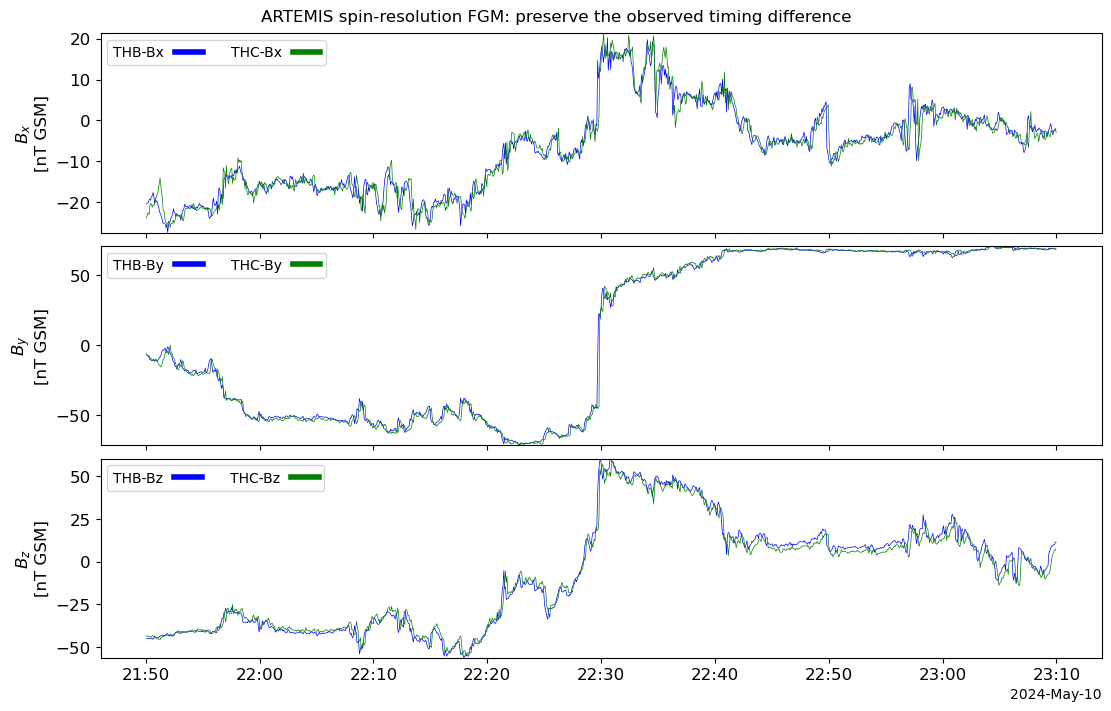

In [5]:
# We want to show the X Y, and Z components on separate panels, with each panel showing the data
# for both THEMIS-B and THEMIS-C to show any timing differences

# First we'll split each tplot variable into its components, then we'll combine THEMIS-B and THEMIS-C
# data for each component, then plot the results.

out_vars_b = pyspedas.split_vec('thb_fgs_gsm')
out_vars_c = pyspedas.split_vec('thc_fgs_gsm')

# To combine two variables in one plot panel, you can create a "pseudovariable" by passing a
# list of variables to store_data.  We will pair THB and THC traces component-wise as
# combined_x, combined_y, and combined_z.

for component in ['x', 'y', 'z']:
    pyspedas.store_data('combined_' + component, ['thb_fgs_gsm_' + component, 'thc_fgs_gsm_' + component])
    # Set the ytitle and labels for the combined variable
    pyspedas.options('combined_' + component, 'ytitle', '$B_' + component+"$")
    pyspedas.options('combined_' + component, 'labels', ['THB-B'+component, 'THC-B' + component])
    pyspedas.options('combined_' + component, 'legend_location', 'upper left')
    pyspedas.options('combined_' + component, 'legend_ncols', 2)

# Set the plot title

tplot_options('title',"ARTEMIS spin-resolution FGM: preserve the observed timing difference")
tplot_options('xsize',11)
tplot_options('ysize',7)
# Now plot the combined data
pyspedas.tplot(['combined_x', 'combined_y', 'combined_z'])



The reversal is present at both lunar-distance probes, but it is not simultaneous. That difference is information: we do not shift either series to make the waveforms coincide.

## 3. MMS1 survey magnetic field and position

MMS burst data are unnecessary for this large-scale timing problem. The Level-2 survey FGM product is already 16 samples/s here, much faster than the cadence needed for a several-minute delay. MMS ephemeris is loaded separately in GSE.

In [6]:
mms = pyspedas.projects.mms

mms_fgm_vars = mms.fgm(
    probe="1", trange=trange, data_rate="srvy", level="l2",
    get_support_data=False, time_clip=True,
)
mms_mec_vars = mms.mec(
    probe="1", trange=trange, data_rate="srvy", level="l2",
    datatype="epht89q", varnames=["mms1_mec_r_gse"],
    time_clip=True,
)

print("MMS FGM variables:", mms_fgm_vars)
print("MMS MEC variables:", mms_mec_vars)
for name in ["mms1_fgm_b_gsm_srvy_l2_bvec", "mms1_mec_r_gse"]:
    print(f"{name:29s} cadence={tres(name):7.4f} s  "
          f"coords={get_coords(name)!r}  units={get_units(name)!r}")

01-Oct-26 15:28:46: Loading files for group: probe: 1, drate: srvy, level: l2, datatype: , after sorting and filtering:
01-Oct-26 15:28:46: pydata/mms1/fgm/srvy/l2/2024/05/mms1_fgm_srvy_l2_20240510_v5.451.0.cdf
01-Oct-26 15:28:49: Loading files for group: probe: 1, drate: srvy, level: l2, datatype: epht89q, after sorting and filtering:
01-Oct-26 15:28:49: pydata/mms1/mec/srvy/l2/epht89q/2024/05/mms1_mec_srvy_l2_epht89q_20240510_v2.2.3.cdf


MMS FGM variables: ['mms1_fgm_b_gsm_srvy_l2', 'mms1_fgm_b_gse_srvy_l2', 'mms1_fgm_b_bcs_srvy_l2', 'mms1_fgm_b_dmpa_srvy_l2', 'mms1_fgm_b_dmpa_srvy_l2_bvec', 'mms1_fgm_b_dmpa_srvy_l2_btot', 'mms1_fgm_b_gse_srvy_l2_bvec', 'mms1_fgm_b_gse_srvy_l2_btot', 'mms1_fgm_b_gsm_srvy_l2_bvec', 'mms1_fgm_b_gsm_srvy_l2_btot', 'mms1_fgm_b_bcs_srvy_l2_bvec', 'mms1_fgm_b_bcs_srvy_l2_btot']
MMS MEC variables: ['mms1_mec_r_gse']
mms1_fgm_b_gsm_srvy_l2_bvec   cadence= 0.0625 s  coords='GSM'  units='nT'
mms1_mec_r_gse                cadence=30.0000 s  coords='GSE'  units='km'


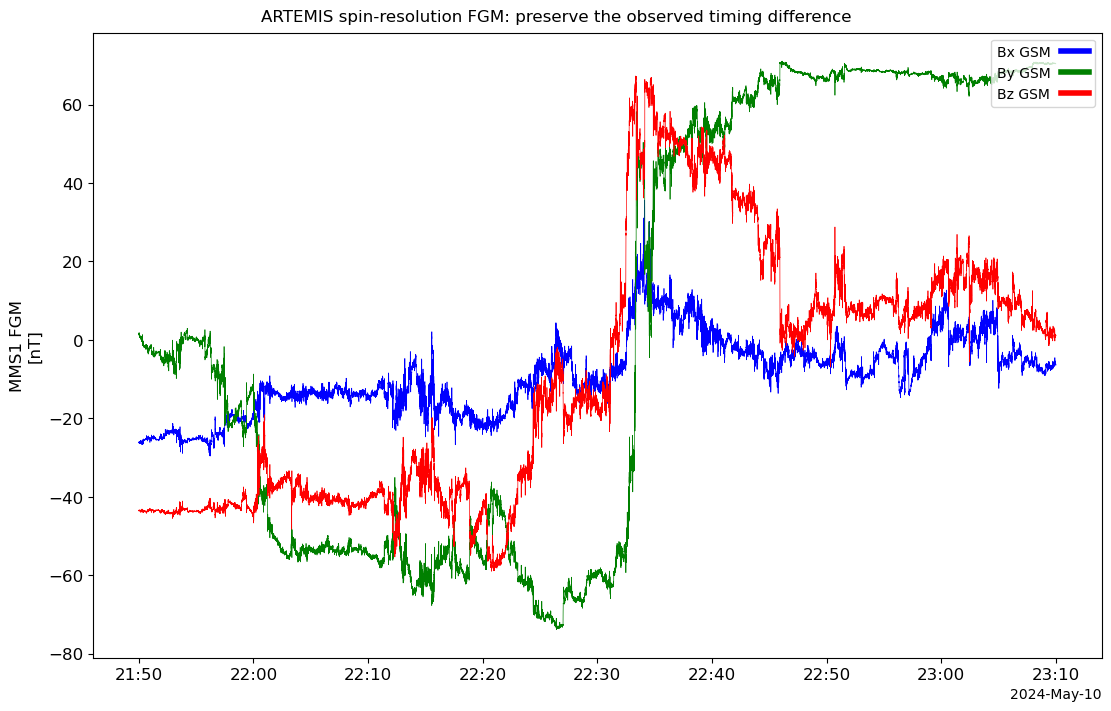

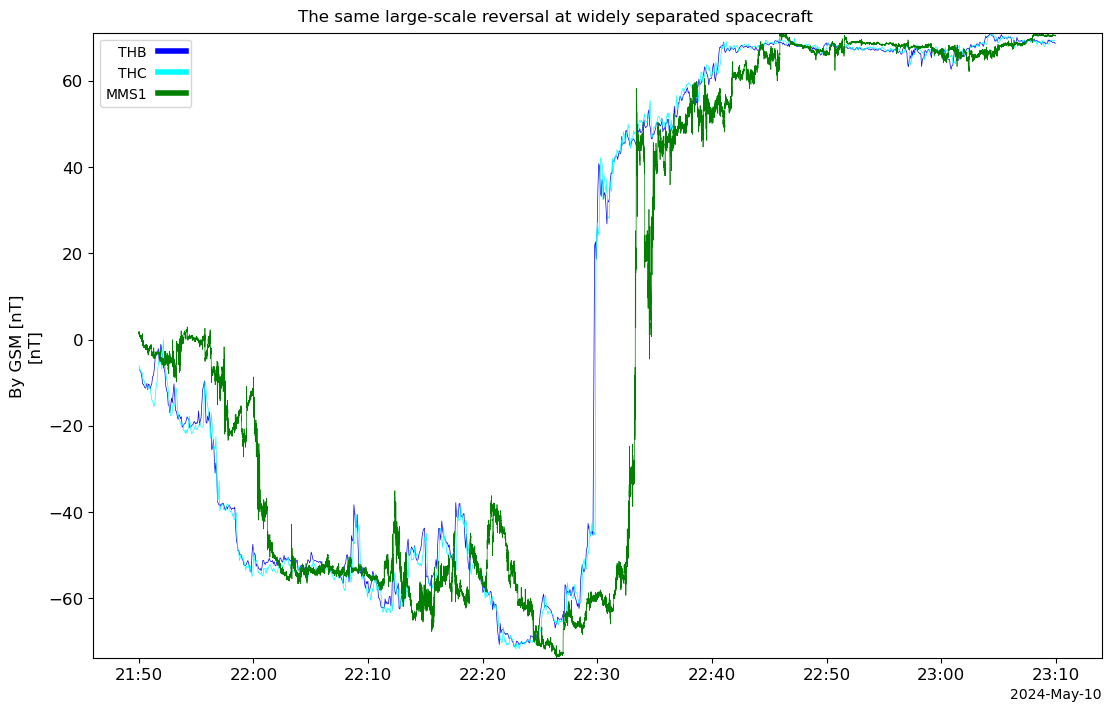

In [7]:
pyspedas.tplot('mms1_fgm_b_gsm_srvy_l2_bvec')
split_names=pyspedas.split_vec('mms1_fgm_b_gsm_srvy_l2_bvec')

pyspedas.store_data('thb_thc_mms1_by',['thb_fgs_gsm_y', 'thc_fgs_gsm_y', 'mms1_fgm_b_gsm_srvy_l2_bvec_y'])
pyspedas.options('thb_thc_mms1_by','ytitle','By GSM [nT]')
pyspedas.options('thb_thc_mms1_by','labels', ['THB', 'THC','MMS1'])
pyspedas.options('thb_thc_mms1_by', 'colors',['blue', 'cyan', 'green'])
pyspedas.options('thb_thc_mms1_by','legend_location', 'upper left')
pyspedas.tplot_options('title',"The same large-scale reversal at widely separated spacecraft")
pyspedas.tplot('thb_thc_mms1_by')
pyspedas.tplot_options('title',None)


### Spacecraft geometry near the flip

The position vectors below are interpolated only for a geometry table, not for the magnetic comparison. THB and THC positions are archived in Earth radii; MMS MEC positions are in km and are converted to Earth radii.

In [8]:
geometry_time = time_double("2024-05-10/22:35:00")

position_vars = {
    "THB / ARTEMIS-1": ("thb_pos_gse", 1.0 / RE_KM),
    "THC / ARTEMIS-2": ("thc_pos_gse", 1.0 / RE_KM),
    "MMS1": ("mms1_mec_r_gse", 1.0 / RE_KM),
}

source_vars = [item[0] for item in position_vars.values()]
interpolated_vars = [f"{name}_geometry_time" for name in source_vars]

# time_interpolate expects an array of target times, even when only
# one interpolation time is requested.
time_interpolate(
    source_vars,
    np.array([geometry_time]),
    method="linear",
    newname=interpolated_vars,
)

geometry = []

for (label, (_, scale)), interpolated_var in zip(
    position_vars.items(), interpolated_vars
):
    data = get_data(interpolated_var)

    # The interpolated variable contains one sample with three components.
    xyz_gse_re = np.asarray(data.y, dtype=float).reshape(-1, 3)[0] * scale
    geometry.append([label, *xyz_gse_re])

geometry_table = pd.DataFrame(
    geometry,
    columns=[
        "Spacecraft",
        "X GSE [R_E]",
        "Y GSE [R_E]",
        "Z GSE [R_E]",
    ],
).round(2)

geometry_table

,Spacecraft,X GSE [R_E],Y GSE [R_E],Z GSE [R_E]
0,THB / ARTEMIS-1,47.70,38.20,5.12
1,THC / ARTEMIS-2,46.34,36.86,5.48
2,MMS1,11.66,-19.02,-5.40


In [9]:
geometry_time = pyspedas.time_double("2024-05-10/22:35:00")

def interp_vector(name, target):
    data = get_data(name)
    return np.array([
        np.interp(target, data.times, data.y[:, component])
        for component in range(3)
    ])

geometry = []
for label, name, scale in [
    ("THB / ARTEMIS-1", "thb_pos_gse", 1.0 / RE_KM),
    ("THC / ARTEMIS-2", "thc_pos_gse", 1.0 / RE_KM),
    ("MMS1", "mms1_mec_r_gse", 1.0 / RE_KM),
]:
    xyz = interp_vector(name, geometry_time) * scale
    geometry.append([label, *xyz])

geometry_table = pd.DataFrame(
    geometry, columns=["Spacecraft", "X GSE [R_E]", "Y GSE [R_E]", "Z GSE [R_E]"]
).round(2)
geometry_table

,Spacecraft,X GSE [R_E],Y GSE [R_E],Z GSE [R_E]
0,THB / ARTEMIS-1,47.70,38.20,5.12
1,THC / ARTEMIS-2,46.34,36.86,5.48
2,MMS1,11.66,-19.02,-5.40


## 4. GOES-18: the paper's magnetosheath reference

For GOES-R spacecraft (16 and later), the PySPEDAS 2.2.0 entry point is `goes.mag`, **not** the legacy `goes.fgm` alias used for GOES 1–15. We request the 0.1 s `hi` product because the paper quotes sub-minute transition times. The daily download is about 200 MB; reruns use the local cache.

The NOAA product supplies vectors named `b_gse` and `b_gsm` in nT. In PySPEDAS 2.2.0, the NetCDF loader does not propagate those coordinate/unit attributes into tplot metadata, so the next cell explicitly attaches the documented GSM/nT labels after checking the returned variable name. This is metadata repair, not a coordinate transformation.

In [10]:
goes = pyspedas.projects.goes

goes_vars = goes.mag(
    probe="18", trange=trange, datatype="hi", time_clip=True,
)
goes_b_gsm = "g18_mag_b_gsm"
if goes_b_gsm not in goes_vars or get_data(goes_b_gsm) is None:
    raise RuntimeError("GOES-18 GSM magnetic field was not loaded")
set_coords(goes_b_gsm, "GSM")
set_units(goes_b_gsm, "nT")

print("Selected GOES variable:", goes_b_gsm)
print("Cadence [s]:", tres(goes_b_gsm))
print("Coordinates:", get_coords(goes_b_gsm), " Units:", get_units(goes_b_gsm))

01-Oct-26 15:28:50: Downloading remote index: https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/goes/goes18/l2/data/magn-l2-hires/2024/05/
01-Oct-26 15:28:52: File is current: goes_data/goes18/l2/data/magn-l2-hires/2024/05/dn_magn-l2-hires_g18_d20240510_v1-0-1.nc
01-Oct-26 15:29:10: time_clip: no valid tplot variables specified
01-Oct-26 15:29:10: Setting coordinate system for g18_mag_b_gsm
01-Oct-26 15:29:10: Setting units for g18_mag_b_gsm


Selected GOES variable: g18_mag_b_gsm
Cadence [s]: 0.09999990463256836
Coordinates: GSM  Units: nT


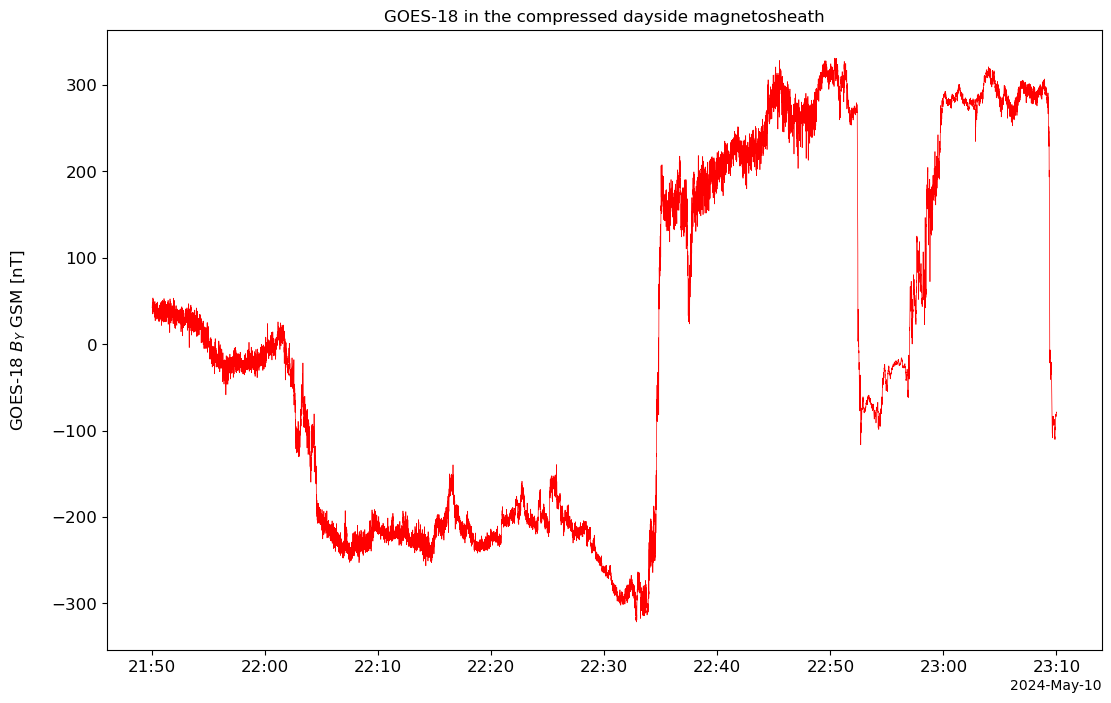

In [11]:
pyspedas.split_vec(goes_b_gsm)
goes_by = goes_b_gsm + '_y'
pyspedas.options(goes_by, 'color', 'red')
pyspedas.options(goes_by, 'ytitle',"GOES-18 $B_Y$ GSM [nT]")
pyspedas.options(goes_by, 'title',"GOES-18 in the compressed dayside magnetosheath")
pyspedas.tplot(goes_b_gsm+'_y')

Ohtani et al. infer that GOES-18 was in the postnoon magnetosheath during the flip and reentered the magnetosphere around 22:52 UT. The magnetosheath field is compressed: the paper divided the GOES field by four only for its multi-spacecraft display. Any such amplitude scaling leaves timestamps unchanged.

## 5. OMNI solar-wind context—and the essential timestamp caveat

We load the 1-minute high-resolution OMNI product in both GSE/GSM magnetic components, together with speed, density, and dynamic pressure.

> **OMNI HRO is not a raw L1 spacecraft clock.** NASA/SPDF constructs this product from solar-wind monitors and shifts the magnetic/plasma records to the modeled Earth's bow-shock nose. Its record times are target-arrival times, not the original observation times. During this event the source was Wind near L1. OMNI is excellent Earth-arrival context, but its timestamps must not be mixed with raw ARTEMIS observations to infer a propagation speed.

The shifting method assumes convecting planar phase fronts; the documentation also warns that variable shifts can create out-of-sequence arrivals and mixed one-minute averages. See the [NASA/SPDF high-resolution OMNI documentation](https://omniweb.gsfc.nasa.gov/html/omni_min_data.html).

In [12]:
omni_vars = pyspedas.projects.omni.data(
    trange=trange, datatype="1min", level="hro", time_clip=True,
)
omni_selected = [
    "BX_GSE", "BY_GSE", "BZ_GSE", "BY_GSM", "BZ_GSM",
    "flow_speed", "proton_density", "Pressure",
]
missing_omni = [name for name in omni_selected if get_data(name) is None]
if missing_omni:
    raise RuntimeError(f"Missing OMNI variables: {missing_omni}")

# The names encode the delivered frame; attach labels for later checks.
for name in ["BY_GSM", "BZ_GSM"]:
    set_coords(name, "GSM")
    set_units(name, "nT")

print("OMNI loader returned", len(omni_vars), "variables")
for name in omni_selected:
    print(f"{name:15s} cadence={tres(name):5.1f} s  "
          f"units={get_units(name)!r} coords={get_coords(name)!r}")

01-Oct-26 15:29:10: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/omni/omni_cdaweb/hro_1min/2024/
01-Oct-26 15:29:12: File is current: omni_data/hro_1min/2024/omni_hro_1min_20240501_v01.cdf
01-Oct-26 15:29:13: Setting coordinate system for BY_GSM
01-Oct-26 15:29:13: Setting units for BY_GSM
01-Oct-26 15:29:13: Setting coordinate system for BZ_GSM
01-Oct-26 15:29:13: Setting units for BZ_GSM


OMNI loader returned 42 variables
BX_GSE          cadence= 60.0 s  units='nT' coords=None
BY_GSE          cadence= 60.0 s  units='nT' coords=None
BZ_GSE          cadence= 60.0 s  units='nT' coords=None
BY_GSM          cadence= 60.0 s  units='nT' coords='GSM'
BZ_GSM          cadence= 60.0 s  units='nT' coords='GSM'
flow_speed      cadence= 60.0 s  units='km/s' coords=None
proton_density  cadence= 60.0 s  units='n/cc' coords=None
Pressure        cadence= 60.0 s  units='nPa' coords=None


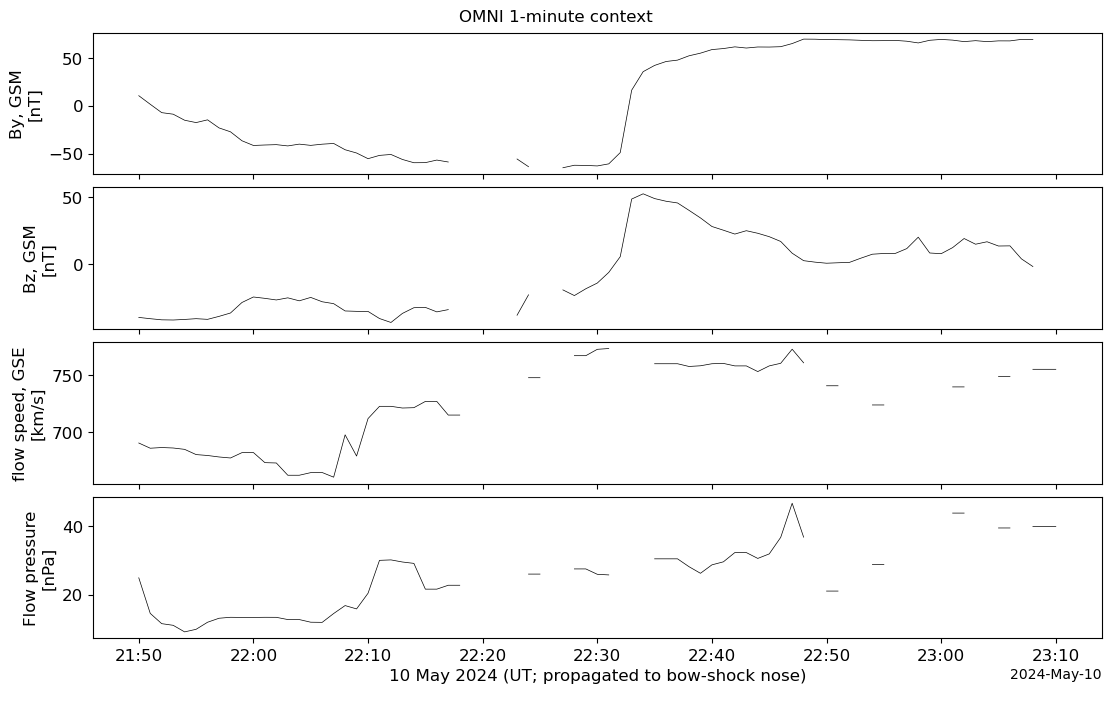

In [13]:
pyspedas.tplot_options('title',"OMNI 1-minute context")
pyspedas.options('Pressure','xtitle',"10 May 2024 (UT; propagated to bow-shock nose)")
pyspedas.tplot(['BY_GSM', 'BZ_GSM', 'flow_speed', 'Pressure'])
pyspedas.tplot_options('title',None)

## 6. A common-coordinate $B_Y$ comparison

Every trace below is GSM $B_Y$. GOES-18 is multiplied by 0.25 for display because the magnetosheath field was strongly compressed. OMNI retains its propagated bow-shock-nose timestamps; the other spacecraft retain their observation timestamps.

First inspect the comparison without event markers. Can you identify the large negative-to-positive transition in every trace? Notice the different waveforms and cadences.

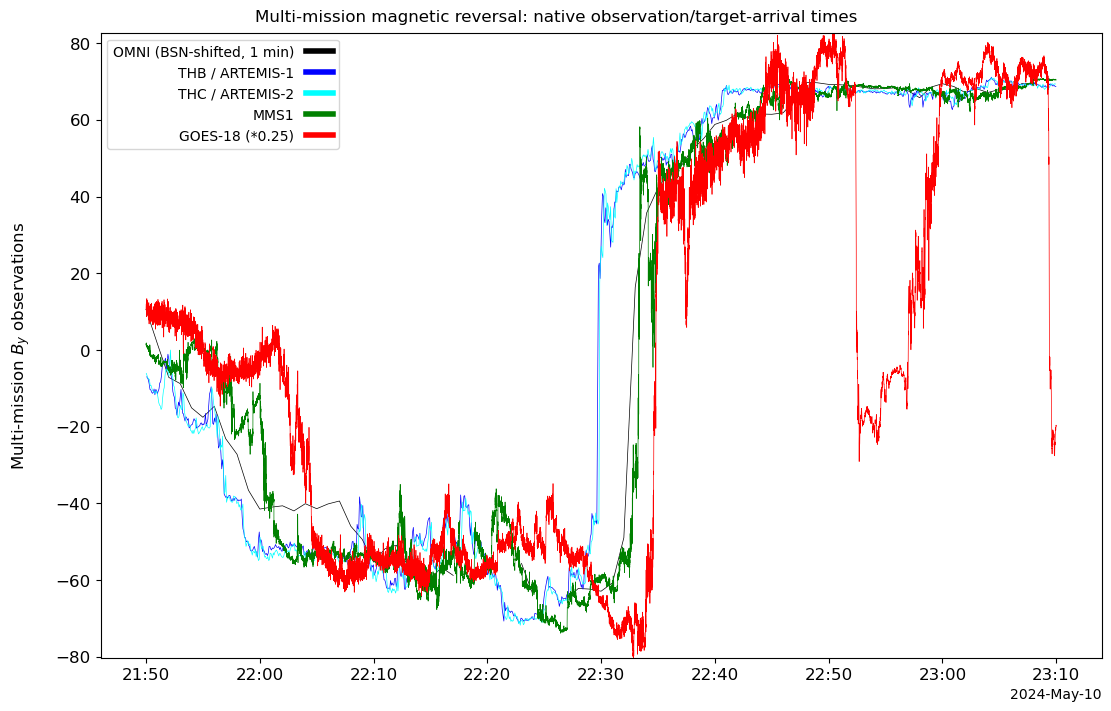

In [14]:
# Rescale GOES-18 By data
d=get_data(goes_by)
rescaled_y = d.y*0.25
pyspedas.store_data('goes_by_rescaled',data={'x':d.times, 'y':rescaled_y})
pyspedas.store_data('by_combined',data=['BY_GSM','thb_fgs_gsm_y', 'thc_fgs_gsm_y', 'mms1_fgm_b_gsm_srvy_l2_bvec_y', 'goes_by_rescaled'])
pyspedas.options('by_combined','colors',['black','blue','cyan','green','red'])
pyspedas.options('by_combined','labels',["OMNI (BSN-shifted, 1 min)","THB / ARTEMIS-1","THC / ARTEMIS-2","MMS1", "GOES-18 (*0.25)"])
pyspedas.options('by_combined','legend_location', 'upper left')
pyspedas.options('by_combined','ytitle', 'Multi-mission $B_y$ observations')
tplot_options('title',"Multi-mission magnetic reversal: native observation/target-arrival times")
pyspedas.tplot('by_combined')

Now add the two GOES-18 times reported by Ohtani et al. These guides are references for comparison, not fitted results.

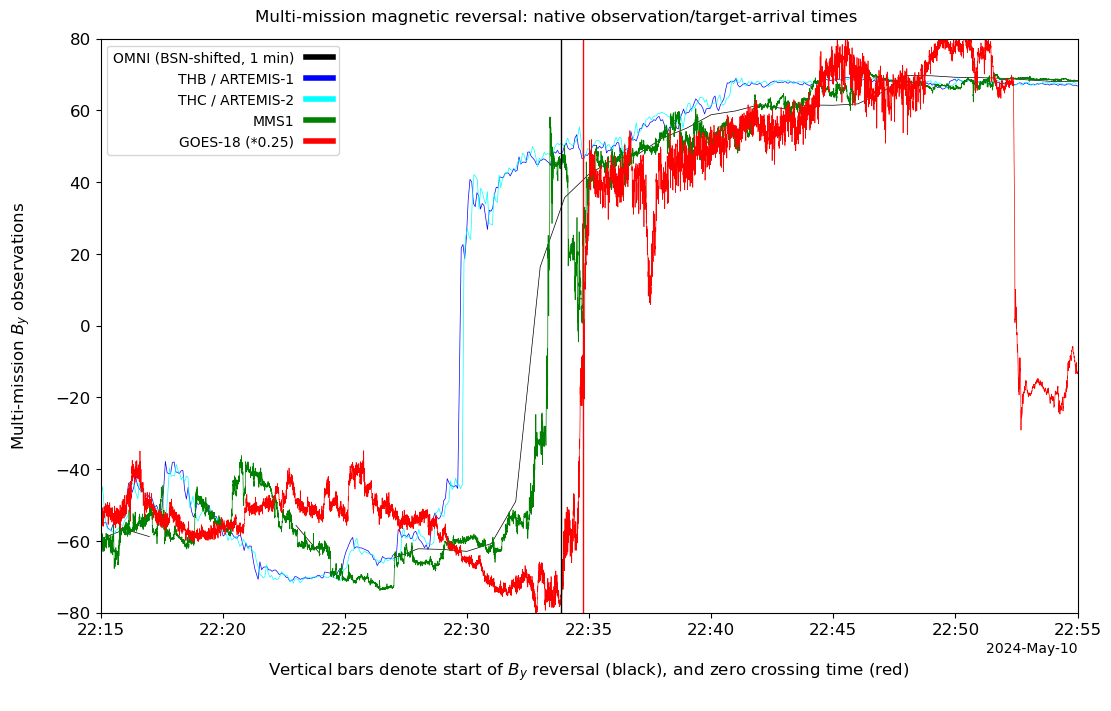

In [15]:
timebar(time_double(by_flip_start),'goes_by_rescaled',color='black')
timebar(time_double(by_zero_time),'goes_by_rescaled',color='red')
options('goes_by_rescaled','xtitle',"\nVertical bars denote start of $B_y$ reversal (black), and zero crossing time (red)")
options('by_combined','yrange',[-80.0, 80.0])
pyspedas.tplot('by_combined', trange=["2024-05-10 22:15","2024-05-10 22:55"])

## 7. Ground magnetometers: six midday stations from the paper

Ohtani et al. examined 12 auroral stations. We start with the six-station midday chain: Deadhorse (DED), Barrow (BRW), Fort Yukon (FYU), Eagle (EAG), College (CMO), and Gakona (GAK).

The THEMIS GMAG CDF metadata describe the vectors as **HEZ**:

- $H$: local magnetic north;
- $E$: local magnetic east;
- $Z$: vertically downward.

The paper instead uses the SuperMAG **N disturbance** component, produced by the SuperMAG baseline/rotation procedure. The directions are closely related, but the processing is not identical. We therefore call the first component $H$, center it only for display/correlation, and do not claim to reproduce the paper's absolute SuperMAG $N$ values or zero crossing.

In [16]:
ground_sites = {
    "DED": {"loader": "ded",  "name": "Deadhorse",  "lat": 70.4, "lon": 211.2},
    "BRW": {"loader": "brw",  "name": "Barrow",     "lat": 71.3, "lon": 203.4},
    "FYU": {"loader": "fykn", "name": "Fort Yukon", "lat": 66.6, "lon": 214.8},
    "EAG": {"loader": "eagl", "name": "Eagle",      "lat": 64.8, "lon": 218.8},
    "CMO": {"loader": "cmo",  "name": "College",    "lat": 64.9, "lon": 212.1},
    "GAK": {"loader": "gako", "name": "Gakona",     "lat": 62.4, "lon": 214.9},
}

ground_vars = themis.gmag(
    sites=[site["loader"] for site in ground_sites.values()],
    trange=trange, time_clip=True,
)
print("Ground variables:", ground_vars)
for code_name, site in ground_sites.items():
    variable = f"thg_mag_{site['loader']}"
    metadata = get_data(variable, metadata=True)
    cdf_attrs = metadata.get("CDF", {}).get("VATT", {})
    print(code_name, variable,
          "cadence=", round(tres(variable), 4), "s",
          "coord=", cdf_attrs.get("COORDINATE_SYSTEM"),
          "description=", cdf_attrs.get("CATDESC"))

01-Oct-26 15:29:15: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thg/l2/mag/ded/2024/
01-Oct-26 15:29:16: File is current: themis_data/thg/l2/mag/ded/2024/thg_l2_mag_ded_20240510_v01.cdf
01-Oct-26 15:29:16: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thg/l2/mag/brw/2024/
01-Oct-26 15:29:17: File is current: themis_data/thg/l2/mag/brw/2024/thg_l2_mag_brw_20240510_v01.cdf
01-Oct-26 15:29:17: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thg/l2/mag/fykn/2024/
01-Oct-26 15:29:19: File is current: themis_data/thg/l2/mag/fykn/2024/thg_l2_mag_fykn_20240510_v01.cdf
01-Oct-26 15:29:19: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thg/l2/mag/eagl/2024/
01-Oct-26 15:29:20: File is current: themis_data/thg/l2/mag/eagl/2024/thg_l2_mag_eagl_20240510_v01.cdf
01-Oct-26 15:29:20: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/thg/l2/mag/cmo/2024/
01-Oct-26 15:29:21: File is current

Ground variables: ['thg_mag_brw', 'thg_mag_cmo', 'thg_mag_ded', 'thg_mag_eagl', 'thg_mag_fykn', 'thg_mag_gako']
DED thg_mag_ded cadence= 1.0 s coord= HEZ description= Magnetic field variation B in HEZ vector components
BRW thg_mag_brw cadence= 1.0 s coord= HEZ description= Magnetic field variation B in HEZ vector components
FYU thg_mag_fykn cadence= 1.0008 s coord= HEZ description= Magnetic field variation B in HEZ vector components
EAG thg_mag_eagl cadence= 1.0008 s coord= HEZ description= Magnetic field variation B in HEZ vector components
CMO thg_mag_cmo cadence= 1.0 s coord= HEZ description= Magnetic field variation B in HEZ vector components
GAK thg_mag_gako cadence= 1.0008 s coord= HEZ description= Magnetic field variation B in HEZ vector components


Median of thg_mag_brw_h is 9393.32 nT
Median of thg_mag_cmo_h is 12720.68 nT
Median of thg_mag_ded_h is 9276.23 nT
Median of thg_mag_eagl_h is 12505.16 nT
Median of thg_mag_fykn_h is 11165.35 nT
Median of thg_mag_gako_h is 13838.38 nT


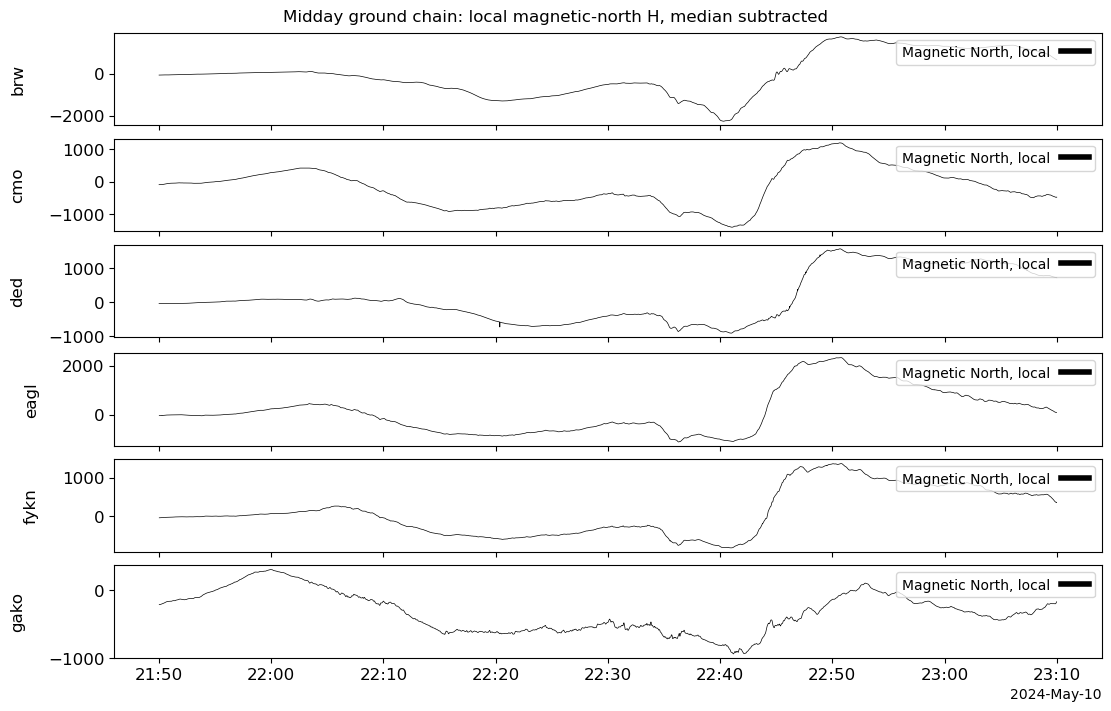

In [17]:

h_comps = []

for v in ground_vars:
    split_vec(v, suffix=["_h","_e","_z"])
    site = v[8:]
    options(v + '_h', 'ytitle', site)
    h_comps.append(v + '_h')

#  For each site, compute a median during a more quiet interval, then subtract that median from the
#  entire data set.

median_interval = time_double([
    "2024-05-10 21:50",
    "2024-05-10 22:00",
])

for y in h_comps:
    d = get_data(y)

    in_interval = (
        (d.times >= median_interval[0])
        & (d.times <= median_interval[1])
    )

    median = np.nanmedian(d.y[in_interval])
    print(f"Median of {y} is {median:.2f} nT")

    store_data(
        y,
        data={
            "x": d.times,
            "y": d.y - median,
        },
        attr_dict=get_data(y, metadata=True),
    )

tplot_options('title',"Midday ground chain: local magnetic-north H, median subtracted")
tplot(h_comps)

Most stations begin their sharp reversal near 22:41–22:42 UT, while the steepest part and any chosen zero level can occur later. The distinction between *start*, *zero crossing*, and *maximum gradient* matters when quoting a delay.

### Map the station chain with `tplot_map`

The coordinates below are the geographic locations tabulated by Ohtani et al. Longitudes greater than 180°E are converted to the usual negative-west map convention. The map is geographic, not magnetic; it provides spatial context without implying that geographic latitude equals magnetic latitude.

01-Oct-26 15:29:24: /Users/jwl/anaconda3/envs/pycharm_py312/lib/python3.12/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()



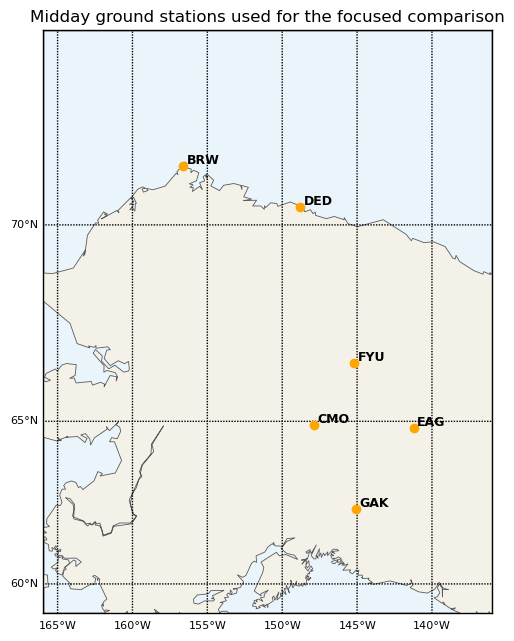

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))

from pyspedas.tplot_tools.MPLPlotter.tplot_map import tplot_map, add_markers

tmap = tplot_map(
    projection="merc", resolution="l",
    llcrnrlon=-166, llcrnrlat=59,
    urcrnrlon=-136, urcrnrlat=74,
    ax=ax,
)
tmap.add_map_boundary(fill_color="#eaf4fb")
tmap.add_fillcontinents(color="#f4f1e8", lake_color="#eaf4fb")
tmap.add_coastlines(linewidth=0.6, color="0.35")
tmap.drawparallels(np.arange(60, 75, 5), labels=[1, 0, 0, 0], fontsize=8)
tmap.drawmeridians(np.arange(-165, -135, 5), labels=[0, 0, 0, 1], fontsize=8)

for code_name, site in ground_sites.items():
    lon = site["lon"] - 360 if site["lon"] > 180 else site["lon"]
    add_markers(
        coords=np.array([1.0, site["lat"], lon]), tmap=tmap,
        marker="o", color="orange", ms=6,
    )
    x, y = tmap(lon, site["lat"])
    ax.text(x + 25000, y + 18000, code_name, fontsize=9, weight="bold")
ax.set_title("Midday ground stations used for the focused comparison")
fig.tight_layout()

## 8. Apply the paper's +570 s shift—without fitting it

The paper's 570 s value is a **GOES-18 magnetosheath-to-ground** shift. It is not an L1-to-ground delay and not an ARTEMIS-to-ground delay. We first apply it as a reported value and compare standardized shapes. Standardization removes the unrelated amplitudes and baselines; it does not change timestamps.

In [19]:
goes_by

'g18_mag_b_gsm_y'

01-Oct-26 15:29:24: avg_data was applied to: g18_by_10s
01-Oct-26 15:29:24: avg_data was applied to: brw_h_10s
01-Oct-26 15:29:24: Setting units for g18_by_10s_z
01-Oct-26 15:29:24: Setting units for brw_h_10s_z


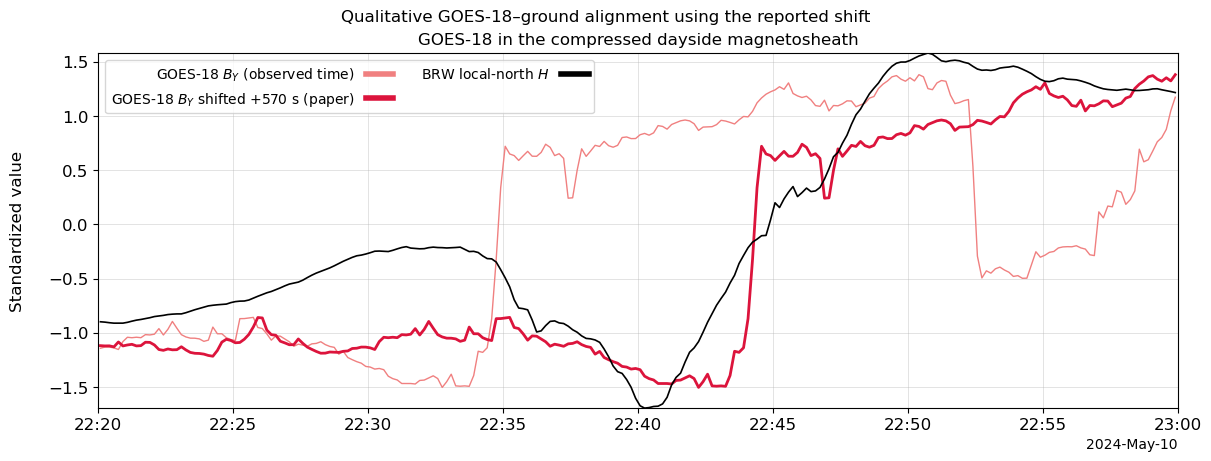

In [20]:
# Put both inputs on a common 10 s time grid.
common_cadence_s = 10
common_times = range(
    int(time_double(trange[0])),
    int(time_double(trange[1])) + 1,
    common_cadence_s,
)

common_cadence_s = 10

avg_data(
    ["g18_mag_b_gsm_y", "thg_mag_brw_h"],
    trange=[
        time_double(trange[0]),
        time_double(trange[1]),
    ],
    res=common_cadence_s,
    newname=["g18_by_10s", "brw_h_10s"],
)
display_trange = [
    "2024-05-10/22:20",
    "2024-05-10/23:00",
]


def standardize_tvar(source, output, stats_trange):
    """Standardize a tplot variable using statistics from stats_trange."""
    data = get_data(source)
    values = np.asarray(data.y, dtype=float)

    start = time_double(stats_trange[0])
    stop = time_double(stats_trange[1])
    in_window = (
        (data.times >= start)
        & (data.times <= stop)
        & np.isfinite(values)
    )

    if in_window.sum() < 2:
        raise ValueError(
            f"{source!r} has too few valid samples in {stats_trange}"
        )

    center = np.nanmean(values[in_window])
    scale = np.nanstd(values[in_window], ddof=1)

    if not np.isfinite(scale) or scale == 0:
        raise ValueError(f"{source!r} has zero or invalid standard deviation")

    store_data(
        output,
        data={
            "x": data.times,
            "y": (values - center) / scale,
        },
        attr_dict=get_data(source, metadata=True),
    )
    set_units(output, "1")


standardize_tvar(
    "g18_by_10s",
    "g18_by_10s_z",
    display_trange,
)
standardize_tvar(
    "brw_h_10s",
    "brw_h_10s_z",
    display_trange,
)

# Apply the paper-reported +570 s GOES-18-to-ground shift.
g18_data = get_data("g18_by_10s_z")

store_data(
    "g18_by_10s_z_shifted_570s",
    data={
        "x": g18_data.times + paper_ground_lag_s,
        "y": g18_data.y,
    },
    attr_dict=get_data("g18_by_10s_z", metadata=True),
)

# Combine the three traces into one tplot panel.
comparison_var = "g18_brw_570s_comparison"
store_data(
    comparison_var,
    data=[
        "g18_by_10s_z",
        "g18_by_10s_z_shifted_570s",
        "brw_h_10s_z",
    ],
)

options(
    comparison_var,
    opt_dict={
        "colors": ["lightcoral", "crimson", "black"],
        "line_width": [1.0, 2.0, 1.2],
        "legend_names": [
            r"GOES-18 $B_Y$ (observed time)",
            r"GOES-18 $B_Y$ shifted +570 s (paper)",
            r"BRW local-north $H$",
        ],
        "legend_location": "upper left",
        "legend_ncols": 2,
        "ytitle": "Standardized value",
        "xtitle": "10 May 2024 (UT)",
        "grid": True,
        "data_gap": 30,
    },
)

tplot_options(
    "title_text",
    "Qualitative GOES-18–ground alignment using the reported shift",
)
tplot_options("xsize", 12)
tplot_options("ysize", 4.5)
tplot_options("grid", True)

tplot(
    comparison_var,
    trange=display_trange,
)

## 9. Estimate the lag independently

We now use a predeclared, timestamp-aware workflow:

1. average both series to 10 s;
2. select a GOES reference interval from 22:25 through 22:44:59 UT, wide enough to include the main sequence rather than only one sample;
3. for each nonnegative lag from 0 to 900 s, compare GOES at time $t$ with ground $H$ at $t+\tau$;
4. use only finite pairs—do not bridge gaps;
5. demean and normalize each valid pair, then maximize the **signed** correlation.

The expected ground response has the same sign as $B_Y$ in the Northern Hemisphere midday sector, so taking an absolute correlation would discard useful physics. This simple coefficient is not a causal transfer-function model, and adjacent lag values are not statistically independent.

In [21]:
reference_window = time_double([
    "2024-05-10 22:25:00",
    "2024-05-10 22:44:59",
])

candidate_lags_s = np.arange(0, 901, 10)


def lag_correlation(
    reference_name,
    response_name,
    lags_s,
    window,
    min_pairs=20,
    time_tolerance_s=1e-3,
):
    """
    Correlate reference(t) with response(t + lag).

    Both input tplot variables should already be on the same time grid.
    Missing values and unmatched timestamps are excluded.
    """
    reference_data = get_data(reference_name)
    response_data = get_data(response_name)

    reference_times = np.asarray(reference_data.times, dtype=float)
    reference_values = np.asarray(reference_data.y, dtype=float).squeeze()

    response_times = np.asarray(response_data.times, dtype=float)
    response_values = np.asarray(response_data.y, dtype=float).squeeze()

    # Restrict only the reference series to the analysis window.
    in_window = (
        (reference_times >= window[0])
        & (reference_times <= window[1])
    )

    reference_times = reference_times[in_window]
    reference_values = reference_values[in_window]

    correlations = []
    pair_counts = []

    for lag_s in lags_s:
        target_times = reference_times + float(lag_s)

        # Locate each target time in the response time array.
        response_indices = np.searchsorted(
            response_times,
            target_times,
        )

        matched_response = np.full(
            reference_values.shape,
            np.nan,
            dtype=float,
        )

        in_bounds = response_indices < response_times.size
        bounded_positions = np.flatnonzero(in_bounds)
        bounded_indices = response_indices[in_bounds]

        # Reject timestamps that are not actually on the common grid.
        time_matches = np.isclose(
            response_times[bounded_indices],
            target_times[in_bounds],
            rtol=0.0,
            atol=time_tolerance_s,
        )

        matched_positions = bounded_positions[time_matches]
        matched_indices = bounded_indices[time_matches]

        matched_response[matched_positions] = (
            response_values[matched_indices]
        )

        valid = (
            np.isfinite(reference_values)
            & np.isfinite(matched_response)
        )
        pair_count = int(valid.sum())
        pair_counts.append(pair_count)

        if pair_count < min_pairs:
            correlations.append(np.nan)
            continue

        x = reference_values[valid]
        y = matched_response[valid]

        x = x - np.mean(x)
        y = y - np.mean(y)

        denominator = np.sqrt(
            np.dot(x, x) * np.dot(y, y)
        )

        correlation = (
            np.dot(x, y) / denominator
            if denominator > 0
            else np.nan
        )
        correlations.append(correlation)

    return (
        np.asarray(correlations),
        np.asarray(pair_counts),
    )


brw_correlation, brw_pair_counts = lag_correlation(
    "g18_by_10s",
    "brw_h_10s",
    candidate_lags_s,
    reference_window,
)

if np.all(np.isnan(brw_correlation)):
    raise RuntimeError("No candidate lag had enough valid data pairs")

best_index = int(np.nanargmax(brw_correlation))
best_lag_s = int(candidate_lags_s[best_index])
best_correlation = float(brw_correlation[best_index])

print(
    f"Best BRW lag = {best_lag_s} s "
    f"({best_lag_s / 60:.2f} min)"
)
print(f"Signed correlation = {best_correlation:.3f}")
print(
    f"Valid 10 s pairs = "
    f"{brw_pair_counts[best_index]}"
)

Best BRW lag = 570 s (9.50 min)
Signed correlation = 0.942
Valid 10 s pairs = 120


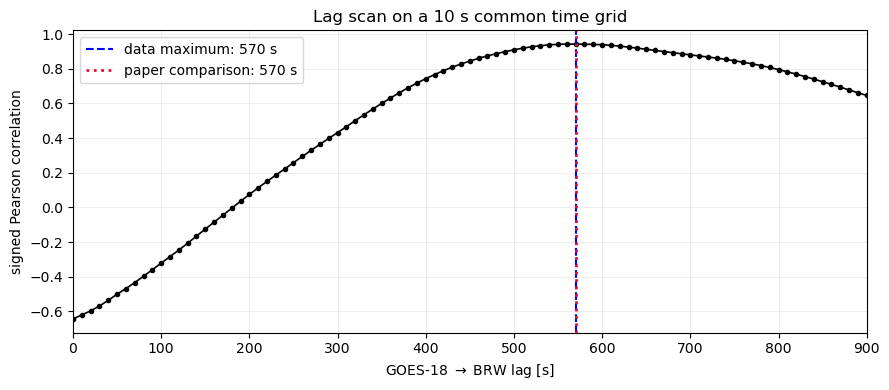

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    candidate_lags_s,
    brw_correlation,
    color="black",
    marker="o",
    ms=3,
    lw=1.2,
)
ax.axvline(
    best_lag_s,
    color="blue",
    ls="--",
    lw=1.5,
    label=f"data maximum: {best_lag_s} s",
)
ax.axvline(
    paper_ground_lag_s,
    color="crimson",
    ls=":",
    lw=2,
    label=f"paper comparison: {paper_ground_lag_s} s",
)
ax.set_xlim(candidate_lags_s[0], candidate_lags_s[-1])
ax.set_xlabel(r"GOES-18 $\rightarrow$ BRW lag [s]")
ax.set_ylabel("signed Pearson correlation")
ax.grid(alpha=0.3)
ax.legend()
ax.set_title("Lag scan on a 10 s common time grid")
fig.tight_layout()

Agreement with 570 s is encouraging, but it is not guaranteed for every station or analysis window. A broad step-like feature can produce a broad correlation peak, and the magnetosphere/ionosphere is a responding system rather than a passive delay line.

### Station dependence

Apply exactly the same window and method to all six stations. This is a useful guard against treating one favorable result as universal.

In [23]:
if len(h_comps) != len(ground_sites):
    raise ValueError(
        "h_comps and ground_sites must contain the same number of stations"
    )

# This assumes h_comps was constructed in the same order as ground_sites.
ground_h_vars = dict(zip(ground_sites.keys(), h_comps))

station_lag_rows = []
station_correlations = {}

averaging_trange = time_double(trange)

for code_name, site in ground_sites.items():
    h_var = ground_h_vars[code_name]
    h_10s_var = f"{h_var}_10s"

    # Average and decimate the ground H component to the same 10 s
    # cadence used for g18_by_10s.
    avg_data(
        h_var,
        trange=averaging_trange,
        res=10,
        newname=h_10s_var,
    )

    correlation, pair_counts = lag_correlation(
        "g18_by_10s",
        h_10s_var,
        candidate_lags_s,
        reference_window,
    )

    if np.all(np.isnan(correlation)):
        print(f"{code_name}: no lag had enough valid sample pairs")
        best_lag_s = np.nan
        best_lag_min = np.nan
        best_correlation = np.nan
        valid_pairs = 0
    else:
        best_index = int(np.nanargmax(correlation))
        best_lag_s = int(candidate_lags_s[best_index])
        best_lag_min = best_lag_s / 60.0
        best_correlation = float(correlation[best_index])
        valid_pairs = int(pair_counts[best_index])

    station_lag_rows.append({
        "Station": code_name,
        "Best lag [s]": best_lag_s,
        "Best lag [min]": best_lag_min,
        "Correlation": best_correlation,
        "Valid pairs": valid_pairs,
    })

    station_correlations[code_name] = correlation


station_lags = pd.DataFrame(station_lag_rows).round({
    "Best lag [min]": 2,
    "Correlation": 3,
})

station_lags

01-Oct-26 15:29:25: avg_data was applied to: thg_mag_brw_h_10s
01-Oct-26 15:29:25: avg_data was applied to: thg_mag_cmo_h_10s
01-Oct-26 15:29:25: avg_data was applied to: thg_mag_ded_h_10s
01-Oct-26 15:29:25: avg_data was applied to: thg_mag_eagl_h_10s
01-Oct-26 15:29:25: avg_data was applied to: thg_mag_fykn_h_10s
01-Oct-26 15:29:25: avg_data was applied to: thg_mag_gako_h_10s


,Station,Best lag [s],Best lag [min],Correlation,Valid pairs
0,DED,570,9.50,0.942,120
1,BRW,560,9.33,0.968,120
2,FYU,720,12.00,0.952,120
3,EAG,560,9.33,0.965,120
4,CMO,570,9.50,0.966,120
5,GAK,580,9.67,0.925,120


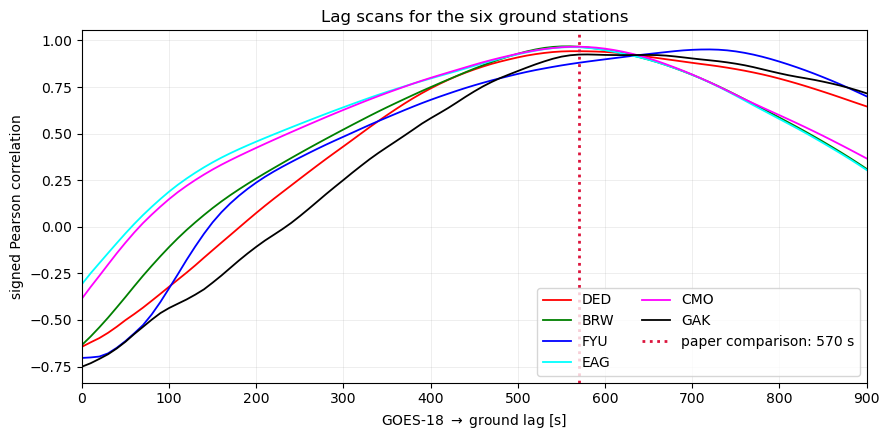

In [24]:
fig, ax = plt.subplots(figsize=(9, 4.5))
station_colors = ["red", "green", "blue", "cyan", "magenta", "black"]

for (code_name, correlation), color in zip(
    station_correlations.items(), station_colors
):
    ax.plot(
        candidate_lags_s,
        correlation,
        color=color,
        lw=1.3,
        label=code_name,
    )

ax.axvline(
    paper_ground_lag_s,
    color="crimson",
    ls=":",
    lw=2,
    label=f"paper comparison: {paper_ground_lag_s} s",
)
ax.set_xlim(candidate_lags_s[0], candidate_lags_s[-1])
ax.set_xlabel(r"GOES-18 $\rightarrow$ ground lag [s]")
ax.set_ylabel("signed Pearson correlation")
ax.grid(alpha=0.3)
ax.legend(ncol=2)
ax.set_title("Lag scans for the six ground stations")
fig.tight_layout()

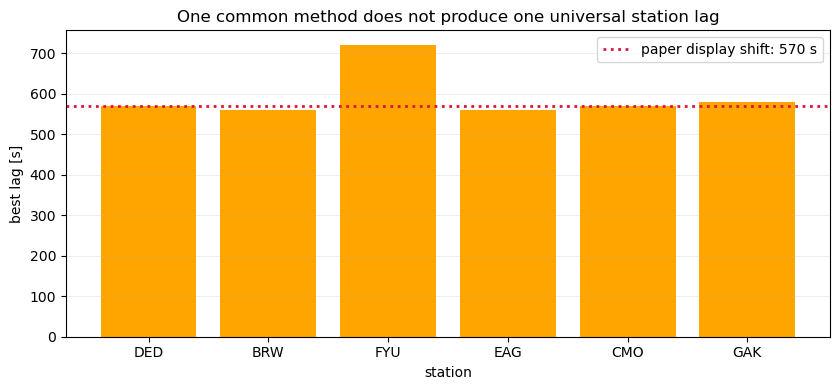

In [25]:
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(station_lags["Station"], station_lags["Best lag [s]"],
       color="orange")
ax.axhline(paper_ground_lag_s, color="crimson", ls=":", lw=2,
           label="paper display shift: 570 s")
ax.set_ylabel("best lag [s]")
ax.set_xlabel("station")
ax.grid(axis="y", alpha=0.3)
ax.legend()
ax.set_title("One common method does not produce one universal station lag")
fig.tight_layout()

## 10. An observation timeline from one objective marker

For a compact propagation table we use the time of the largest positive slope:

- spacecraft and BRW are first averaged to 10 s, then smoothed with a centered 30 s mean before differencing;
- OMNI remains at its native 60 s cadence, so its marker is only minute-scale;
- spacecraft are searched from 22:30–22:40 UT;
- BRW is searched from 22:38–22:50 UT.

This marker is reproducible, but it is not identical to the paper's manually identified start or zero-crossing times. Delays are reported relative to the GOES-18 maximum-gradient marker.

In [27]:
# Find the time of the largest positive dB/dt in a tplot variable.
# avg_data timestamps each 10 s average at the center of its bin.
def maximum_gradient_time(
    source_var,
    window,
    prefix,
    cadence_s=10,
    smooth_width=3,
):
    averaged_var = f"{prefix}_{cadence_s}s"
    smoothed_var = f"{prefix}_{cadence_s}s_smoothed"
    slope_var = f"{prefix}_{cadence_s}s_slope"
    search_var = f"{slope_var}_search"

    # Average and decimate to the requested cadence.
    avg_data(
        source_var,
        res=cadence_s,
        newname=averaged_var,
    )

    # Three-point centered boxcar, corresponding to the previous
    # rolling(3, center=True) operation.
    tsmooth(
        averaged_var,
        width=smooth_width,
        preserve_nans=True,
        newname=smoothed_var,
    )

    # deriv_data uses the actual timestamps, producing dB/dt.
    deriv_data(
        smoothed_var,
        newname=slope_var,
    )

    # Restrict only the maximum search, not the averaging/smoothing.
    # This preserves samples on both sides of the search interval.
    time_clip(
        slope_var,
        window[0],
        window[1],
        newname=search_var,
    )

    data = get_data(search_var)
    values = np.asarray(data.y, dtype=float).squeeze()
    valid = np.isfinite(values)

    if not np.any(valid):
        raise ValueError(
            f"No finite slope values for {source_var} in {window}"
        )

    valid_indices = np.flatnonzero(valid)
    maximum_index = valid_indices[np.argmax(values[valid])]

    return float(data.times[maximum_index]), slope_var


# The scalar Y-component tplot variables created earlier in the notebook.
timeline_inputs = {
    "THB": (
        "thb_fgs_gsm_y",
        "lunar-distance upstream",
        "~4.3 s",
        "thb_by",
    ),
    "THC": (
        "thc_fgs_gsm_y",
        "lunar-distance upstream",
        "~4.1 s",
        "thc_by",
    ),
    "MMS1": (
        "mms1_fgm_b_gsm_srvy_l2_bvec_y",
        "near-Earth solar wind / magnetosheath",
        "0.0625 s",
        "mms1_by",
    ),
    "GOES-18": (
        "g18_mag_b_gsm_y",
        "dayside magnetosheath",
        "0.1 s",
        "g18_by",
    ),
}

spacecraft_search = [
    "2024-05-10 22:30:00",
    "2024-05-10 22:40:00",
]

marker_times = {}
slope_vars = {}

for name, (source_var, _, _, prefix) in timeline_inputs.items():
    marker_times[name], slope_vars[name] = maximum_gradient_time(
        source_var,
        spacecraft_search,
        prefix,
    )


# Keep OMNI on its native one-minute grid. No averaging, smoothing,
# interpolation, or artificial 10 s timing precision is introduced.
deriv_data(
    "BY_GSM",
    newname="omni_by_gsm_slope",
)

time_clip(
    "omni_by_gsm_slope",
    spacecraft_search[0],
    spacecraft_search[1],
    newname="omni_by_gsm_slope_search",
)

omni_data = get_data("omni_by_gsm_slope_search")
omni_slope = np.asarray(omni_data.y, dtype=float).squeeze()
omni_valid = np.isfinite(omni_slope)

if not np.any(omni_valid):
    raise ValueError("No finite OMNI slope values in the search interval")

omni_indices = np.flatnonzero(omni_valid)
omni_maximum_index = omni_indices[np.argmax(omni_slope[omni_valid])]
marker_times["OMNI"] = float(omni_data.times[omni_maximum_index])
slope_vars["OMNI"] = "omni_by_gsm_slope"


# Ground response is searched in its later time interval.
marker_times["BRW"], slope_vars["BRW"] = maximum_gradient_time(
    "thg_mag_brw_h",
    ["2024-05-10 22:38:00", "2024-05-10 22:50:00"],
    "brw_h",
)


goes_marker = marker_times["GOES-18"]

timeline_rows = [{
    "Dataset": "OMNI",
    "Region / timestamp meaning": "modeled bow-shock-nose arrival",
    "Marker time [UT]": time_string(
        marker_times["OMNI"], fmt="%H:%M:%S"
    ),
    "Delay from GOES marker [s]": int(
        round(marker_times["OMNI"] - goes_marker)
    ),
    "Marker grid": "native 60 s",
}]

for name, (_, region, native_cadence, _) in timeline_inputs.items():
    timeline_rows.append({
        "Dataset": name,
        "Region / timestamp meaning": region,
        "Marker time [UT]": time_string(
            marker_times[name], fmt="%H:%M:%S"
        ),
        "Delay from GOES marker [s]": int(
            round(marker_times[name] - goes_marker)
        ),
        "Marker grid": f"10 s bin centers (native {native_cadence})",
    })

timeline_rows.append({
    "Dataset": "BRW H",
    "Region / timestamp meaning": "ground, local magnetic north",
    "Marker time [UT]": time_string(
        marker_times["BRW"], fmt="%H:%M:%S"
    ),
    "Delay from GOES marker [s]": int(
        round(marker_times["BRW"] - goes_marker)
    ),
    "Marker grid": "10 s bin centers (native 1 s)",
})

timeline = pd.DataFrame(timeline_rows)
timeline

01-Oct-26 15:31:03: avg_data was applied to: thb_by_10s
01-Oct-26 15:31:03: tsmooth was applied to: thb_by_10s_smoothed
01-Oct-26 15:31:03: deriv_data was applied to: thb_by_10s_slope
01-Oct-26 15:31:03: avg_data was applied to: thc_by_10s
01-Oct-26 15:31:03: tsmooth was applied to: thc_by_10s_smoothed
01-Oct-26 15:31:03: deriv_data was applied to: thc_by_10s_slope
01-Oct-26 15:31:03: avg_data was applied to: mms1_by_10s
01-Oct-26 15:31:03: tsmooth was applied to: mms1_by_10s_smoothed
01-Oct-26 15:31:03: deriv_data was applied to: mms1_by_10s_slope
01-Oct-26 15:31:03: avg_data was applied to: g18_by_10s
01-Oct-26 15:31:03: tsmooth was applied to: g18_by_10s_smoothed
01-Oct-26 15:31:03: deriv_data was applied to: g18_by_10s_slope
01-Oct-26 15:31:03: deriv_data was applied to: omni_by_gsm_slope
01-Oct-26 15:31:03: avg_data was applied to: brw_h_10s
01-Oct-26 15:31:03: tsmooth was applied to: brw_h_10s_smoothed
01-Oct-26 15:31:03: deriv_data was applied to: brw_h_10s_slope


,Dataset,Region / timestamp meaning,Marker time [UT],Delay from GOES marker [s],Marker grid
0,OMNI,modeled bow-shock-nose arrival,22:33:00,-105,native 60 s
1,THB,lunar-distance upstream,22:30:05,-280,10 s bin centers (native ~4.3 s)
2,THC,lunar-distance upstream,22:30:05,-280,10 s bin centers (native ~4.1 s)
3,MMS1,near-Earth solar wind / magnetosheath,22:33:15,-90,10 s bin centers (native 0.0625 s)
4,GOES-18,dayside magnetosheath,22:34:45,0,10 s bin centers (native 0.1 s)
5,BRW H,"ground, local magnetic north",22:44:55,610,10 s bin centers (native 1 s)


The ordering is physically suggestive, but the differences do not all measure the same thing. OMNI has already been propagated to a target near Earth. THB/THC, MMS1, and GOES-18 occupy very different locations, while the ground response includes transmission through the magnetopause, magnetospheric reconfiguration, and ionospheric electrodynamics. A single frozen-structure travel time is therefore not a sufficient causal model.

## 11. Exercises

### A — Identify a zero crossing

Using the 0.1 s GOES-18 series, estimate the negative-to-positive $B_Y=0$ crossing without reading `by_zero_time`. Decide whether to smooth first and state the precision justified by your choice. Compare with the paper's approximate 22:34:45 UT value.

### B — Compare spacecraft waveforms

Do THB, THC, MMS1, GOES-18, and OMNI observe exactly the same waveform? Separate possible effects of spatial separation, magnetosheath compression, local structure, cadence, and OMNI's bow-shock-nose time shifting.

### C — Compare lag definitions

Estimate the GOES-18-to-BRW delay from (1) reversal start, (2) a chosen centered zero level, (3) maximum gradient, and (4) cross-correlation. Why need these values not agree?

### D — Change the correlation window

Repeat the lag scan with `22:30–22:40`, `22:32–22:38`, and `22:20–22:50` reference windows. Plot the three curves together. How stable are the peak and its width?

### E — Station dependence

Inspect the six ground traces at their inferred lags. Are the later duskward stations described in the paper expected to respond identically? How might station longitude, magnetic latitude, electrojet structure, induction, and use of raw $H$ rather than SuperMAG $N$ matter?

### F — Cadence and false precision

Repeat the multi-spacecraft marker table at 1-minute cadence. Which timing differences survive? Explain why interpolating one-minute OMNI data onto a 1-second grid does not create 1-second information.

## 12. Scientific takeaway

- A very large GSM $B_Y$ reversal is visible at ARTEMIS, MMS1, GOES-18, and in bow-shock-nose-shifted OMNI context.
- The structure extended across a large part of the dayside system, but its waveform and timestamp differ among locations.
- GOES-18 observed the compressed field in the dayside magnetosheath and is the reference used by Ohtani et al. for the ground delay.
- Midday ground stations show a coherent local-north magnetic reversal several minutes later. The paper reports about 7–8 min for reversal onset and 9–10 min for the subsequent zero crossing; its illustrative GOES-to-ground shift is 570 s.
- A simple 10 s cross-correlation for BRW recovers a comparable lag, while other stations demonstrate real method/location dependence.
- The observed delay combines magnetosheath transport, reconnection-related transmission, magnetospheric response, Alfvénic communication, and ionospheric electrodynamics. It is not automatically the speed of one frozen planar structure.

PySPEDAS makes the multi-mission mechanics compact. The scientific work lies in keeping coordinate frames, timestamp meanings, cadence, preprocessing, and physical interpretation honest.

## References and data notes

- Ohtani, S., et al. (2025), *Ground Magnetic Response to an Extraordinary IMF $B_Y$ Flip During the May 2024 Storm: Travel Time From the Magnetosheath to Dayside High Latitudes*, **JGR: Space Physics**, 130, e2024JA033691. [https://doi.org/10.1029/2024JA033691](https://doi.org/10.1029/2024JA033691)
- NASA/SPDF, *One min and 5-min solar wind data sets at the Earth's bow shock nose*. [OMNI HRO documentation](https://omniweb.gsfc.nasa.gov/html/omni_min_data.html)
- Mission data are loaded through PySPEDAS 2.2.0 from THEMIS/ARTEMIS, MMS, NOAA GOES-R, and NASA/SPDF OMNI archives. Ground stations are provided through the THEMIS GMAG archive; station coordinates here follow Table 1 of Ohtani et al.

## Instructor notes and current caveats

- Validated coverage for 21:50–23:10 UT: THB/THC spin FGM, MMS1 survey FGM, GOES-18 0.1 s MAG, OMNI HRO 1 min, and all six focused ground stations.
- Fresh-run downloads include daily files. The largest are about 200 MB for GOES-18 high-rate MAG and 87 MB for MMS1 survey FGM; reruns use local caches.
- PySPEDAS 2.2.0 uses `pyspedas.projects.goes.mag` for GOES-18. `goes.fgm` is the legacy GOES 1–15 wrapper and returns no GOES-18 magnetic data.
- The GOES NetCDF loader currently does not attach coordinate/unit metadata to tplot variables. The notebook checks the documented `b_gsm` product name and explicitly labels it GSM/nT.
- The THEMIS GMAG first component is local magnetic-north $H$ in HEZ. It is not numerically identical to SuperMAG's baseline-processed $N$ disturbance component used in the paper.
- OMNI HRO times are modeled bow-shock-nose target-arrival times. They are not raw Wind observation times.
- The 570 s result is window- and station-dependent. It must not be presented with 0.1 s precision merely because GOES has 0.1 s samples.